<a href="https://colab.research.google.com/github/paulinaeb/IDaSec-project/blob/exp3/my_exp3/before_evasion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline model for spam detection using LSTM

This notebook implements baseline models for spam detection using datasets such as Enron1, Enron2, and SMS. The goal is to evaluate the performance of these models on detecting spam and ham emails, as well as to explore their robustness when datasets are merged for further study.


Model used:

**Long short term memory (LSTM):**

LSTMs are typically trained to classify the overall meaning or sentiment of the text or to take in a sequence of words as input and predict the next word in the series. These NLP tasks are a good fit for LSTMs because they can handle sequential data well and keep track of previous inputs in “memory.”

**Why LSTM?**

*  Handle sequential data

*  Handle long-term dependencies

*  Handle variable-length inputs

*  Handle a large amount of data



In [ ]:
 !git clone --branch main https://github.com/paulinaeb/IDaSec-project.git

# Libraries

In [ ]:
 !pip uninstall -y torch torchtext

In [ ]:
# !pip install --upgrade torchtext
# !pip install --upgrade torch
 !pip install torch==2.2.0 torchtext==0.17.0

In [ ]:
import warnings as wrn
wrn.filterwarnings('ignore')

import os
import numpy
import pandas as pd
import torch
import torch
from torch.utils.data import DataLoader, Dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt


 # Read datasets

**Datasets:**

Enron1, Enron2, SMS

The datasets used in this notebook include Enron1, Enron2, and SMS. Each dataset contains labeled email/text data with two classes: spam and ham. The following steps were performed for each dataset:

**Loading Phase:**

The datasets were loaded from their respective folders, with separate files for training, testing, and validation splits.

**Preprocessing Phase:**

Columns were renamed to text (email content) and label (spam/ham).
Labels were encoded as:
ham → 0
spam → 1
Exploration:

The datasets were explored to understand their structure, label distribution, and sample rows.

**Merging Phase:**

In order to take a better idea about the model performance over a bigger dataset, I merged the three datasets

In [ ]:
# Path to the dataset folder
dataset_path = "IDaSec-project/dataset"

# List all subfolders in dataset
subfolders = [f.name for f in os.scandir(dataset_path) if f.is_dir()]
print("available datasets:", subfolders)

enron1_path = dataset_path + "/enron1"
enron2_path = dataset_path + "/enron2"
sms_path = dataset_path + "/sms"

enron1_files = os.listdir(enron1_path)
print(f"\nFiles in '{enron1_path}': {enron1_files}")

enron2_files = os.listdir(enron2_path)
print(f"\nFiles in '{enron2_path}': {enron2_files}")

sms_files = os.listdir(sms_path)
print(f"\nFiles in '{sms_path}': {sms_files}")

available datasets: ['enron2', 'enron1', 'sms']

Files in 'IDaSec-project/dataset/enron1': ['enron1_val.csv', 'enron1_test.csv', 'enron1_train.csv']

Files in 'IDaSec-project/dataset/enron2': ['enron2_test.csv', 'enron2_val.csv', 'enron2_train.csv']

Files in 'IDaSec-project/dataset/sms': ['test.csv', 'train.csv', 'val.csv']


## Enron1

In [ ]:
enron1_train = pd.read_csv(enron1_path + "/enron1_train.csv")
enron1_test = pd.read_csv(enron1_path + "/enron1_test.csv")
enron1_val = pd.read_csv(enron1_path + "/enron1_val.csv")

In [ ]:
enron1_train['label'] = enron1_train['target'].map({'ham': 0, 'spam': 1})
enron1_val['label'] = enron1_val['target'].map({'ham': 0, 'spam': 1})
enron1_test['label'] = enron1_test['target'].map({'ham': 0, 'spam': 1})

In [ ]:
enron1_train.head()

,email,target,label
0,"Subject: prom dress shopping hi , just wanted ...",ham,0
1,"Subject: hi agaain hello , welcome to pharm la...",spam,1
2,Subject: feedback monitor error - meter 984132...,ham,0
3,Subject: instructions to remove spyware / adwa...,spam,1
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,spam,1


## Enron2

In [ ]:
enron2_train = pd.read_csv(enron2_path + "/enron2_train.csv")
enron2_test = pd.read_csv(enron2_path + "/enron2_test.csv")
enron2_val = pd.read_csv(enron2_path + "/enron2_val.csv")

In [ ]:
enron2_train['label'] = enron2_train['target'].map({'ham': 0, 'spam': 1})
enron2_test['label'] = enron2_test['target'].map({'ham': 0, 'spam': 1})
enron2_val['label'] = enron2_val['target'].map({'ham': 0, 'spam': 1})

In [ ]:
enron2_train.head()

,email,target,label
0,Subject: membership in the nsf vince : karen m...,ham,0
1,Subject: holiday gift thank you so much for yo...,ham,0
2,"Subject: re : real options vince , if you take...",ham,0
3,"Subject: men charset = windows - 1252 "" > vigo...",spam,1
4,Subject: vaal medz how t pestilent o save on y...,spam,1


## sms

In [ ]:
sms_train = pd.read_csv(sms_path + "/train.csv")
sms_test = pd.read_csv(sms_path + "/test.csv")
sms_val = pd.read_csv(sms_path + "/val.csv")

In [ ]:
sms_train['label'] = sms_train['target'].map({'ham': 0, 'spam': 1})
sms_test['label'] = sms_test['target'].map({'ham': 0, 'spam': 1})
sms_val['label'] = sms_val['target'].map({'ham': 0, 'spam': 1})

In [ ]:
sms_train.head()

,email,target,label
0,What to think no one saying clearly. Ok leave ...,ham,0
1,"FREE RING TONE just text \POLYS\"" to 87131. Th...",spam,1
2,"Trust me. Even if isn't there, its there.",ham,0
3,Hi dear we saw dear. We both are happy. Where ...,ham,0
4,"URGENT, IMPORTANT INFORMATION FOR O2 USER. TOD...",spam,1


## Merged datasets

In [ ]:
# Merge train sets
merged_train = pd.concat([enron1_train, enron2_train, sms_train], ignore_index=True)

# Merge val sets
merged_val = pd.concat([enron1_val, enron2_val, sms_val], ignore_index=True)

# Merge test sets
merged_test = pd.concat([enron1_test, enron2_test, sms_test], ignore_index=True)

In [ ]:
merged_train.head()

,email,target,label
0,"Subject: prom dress shopping hi , just wanted ...",ham,0
1,"Subject: hi agaain hello , welcome to pharm la...",spam,1
2,Subject: feedback monitor error - meter 984132...,ham,0
3,Subject: instructions to remove spyware / adwa...,spam,1
4,Subject: acrobat pro 7 . 0 $ 69 . 95 xp pro op...,spam,1


# The model

In [ ]:
SEED = 42

torch.manual_seed(SEED)
torch.backends.cuda.deterministic = True

## Setup tokenizer and vocabulary

**Tokenization & Vocabulary Setup**

Used SpaCy's tokenizer (en_core_web_sm) to tokenize email text.

Built a vocabulary from merged training data (Enron1, Enron2, SMS) with special tokens <unk> and <pad>.


In [ ]:
# use tokenizer from SpaCy
tokenizer = get_tokenizer("spacy", language="en_core_web_sm")

# define the function only in the email column
def yield_tokens(data_iter):
  for index, row in data_iter.iterrows():
        yield tokenizer(row['email'])

# Merge the training splits of all datasets before building vocab
merged_train = pd.concat([enron1_train, enron2_train, sms_train], ignore_index=True)
vocab = build_vocab_from_iterator(yield_tokens(merged_train), specials=["<unk>", "<pad>"])
vocab.set_default_index(vocab["<unk>"])

# setup label map
label_map = {"ham": 0, "spam": 1}


## Create datasets and dataloaders


**Dataset Preparation**

Created a custom TextDataset class to handle:

* Tokenization using the SpaCy tokenizer.

* Conversion of tokens to numerical indices via the vocabulary.

* Label mapping (ham → 0, spam → 1).

* Applied a collate_batch function to pad sequences dynamically per batch.


**Data Loading**

1. Initialized DataLoader for each dataset (Enron1, Enron2, SMS, and merged) with:

2. set up Batch size = 64.

3. Shuffle for training splits.

4. Custom collation for variable-length sequences.


In [ ]:
class TextDataset(Dataset):
    def __init__(self, data, vocab, tokenizer, label_map):
        self.data = data
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.label_map = label_map

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]  # <-- change this line
        text = torch.tensor(self.vocab(self.tokenizer(item['email'])), dtype=torch.long)
        label = torch.tensor(self.label_map[item['target']], dtype=torch.float)
        return text, label


In [ ]:
def collate_batch(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=vocab["<pad>"])
    labels = torch.stack(labels)
    return padded_texts, lengths, labels


In [ ]:
BATCH_SIZE = 64

############################ Enron1 ######################################
train_dataset_enron1 = TextDataset(enron1_train, vocab, tokenizer, label_map)
val_dataset_enron1 = TextDataset(enron1_val, vocab, tokenizer, label_map)
test_dataset_enron1 = TextDataset(enron1_test, vocab, tokenizer, label_map)

train_loader_enron1 = DataLoader(train_dataset_enron1, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader_enron1 = DataLoader(val_dataset_enron1, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader_enron1 = DataLoader(test_dataset_enron1, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

############################ Enron2 ######################################
train_dataset_enron2 = TextDataset(enron2_train, vocab, tokenizer, label_map)
val_dataset_enron2 = TextDataset(enron2_val, vocab, tokenizer, label_map)
test_dataset_enron2 = TextDataset(enron2_test, vocab, tokenizer, label_map)

train_loader_enron2 = DataLoader(train_dataset_enron2, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader_enron2 = DataLoader(val_dataset_enron2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader_enron2 = DataLoader(test_dataset_enron2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

############################ SMS ######################################
train_dataset_sms = TextDataset(sms_train, vocab, tokenizer, label_map)
val_dataset_sms = TextDataset(sms_val, vocab, tokenizer, label_map)
test_dataset_sms = TextDataset(sms_test, vocab, tokenizer, label_map)

train_loader_sms = DataLoader(train_dataset_sms, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader_sms = DataLoader(val_dataset_sms, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader_sms = DataLoader(test_dataset_sms, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

############################ Merged ######################################
train_dataset_merged = TextDataset(merged_train, vocab, tokenizer, label_map)
val_dataset_merged = TextDataset(merged_val, vocab, tokenizer, label_map)
test_dataset_merged = TextDataset(merged_test, vocab, tokenizer, label_map)

train_loader_merged = DataLoader(train_dataset_merged, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader_merged = DataLoader(val_dataset_merged, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader_merged= DataLoader(test_dataset_merged, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)


## LSTMNet model

**Model Architecture**

LSTMNet: A bidirectional LSTM model with:

* Embedding layer (dim = 100).

* LSTM layers (hidden dim = 64, 2 layers, dropout = 0.2).

* Linear layer for binary classification (output logits).

In [ ]:
import torch.nn as nn

class LSTMNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super(LSTMNet, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout,
                            batch_first=True)

        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_output, (hidden_state, cell_state) = self.lstm(packed_embedded)

        hidden = torch.cat((hidden_state[-2, :, :], hidden_state[-1, :, :]), dim=1)

        logits = self.fc(hidden)

        return logits  # raw logits (no sigmoid)


In [ ]:
# Replacing TEXT.vocab with our new vocab
SIZE_OF_VOCAB = len(vocab)
EMBEDDING_DIM = 100
NUM_HIDDEN_NODES = 64
NUM_OUTPUT_NODES = 1
NUM_LAYERS = 2
BIDIRECTION = True
DROPOUT = 0.2

model = LSTMNet(SIZE_OF_VOCAB,
                EMBEDDING_DIM,
                NUM_HIDDEN_NODES,
                NUM_OUTPUT_NODES,
                NUM_LAYERS,
                BIDIRECTION,
                DROPOUT
               )


## Optimizer and Loss function

**Training Setup**

Loss Function:

 BCEWithLogitsLoss with class-weighted pos_weight to handle imbalance.

---

Optimizer:

 Adam (lr = 1e-4).


In [ ]:
import torch
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# enron1 criterion
enron1_labels = enron1_train['label'].values
enron1_pos_weight = torch.tensor([np.sum(enron1_labels == 0) / np.sum(enron1_labels == 1)], dtype=torch.float).to(device)

# enron2 criterion
enron2_labels = enron2_train['label'].values
enron2_pos_weight = torch.tensor([np.sum(enron2_labels == 0) / np.sum(enron2_labels == 1)], dtype=torch.float).to(device)

# sms criterion
sms_labels = sms_train['label'].values
sms_weight = torch.tensor([np.sum(sms_labels == 0) / np.sum(sms_labels == 1)], dtype=torch.float).to(device)

# merged criterion
merged_labels = merged_train['label'].values
merged_weight = torch.tensor([np.sum(merged_labels == 0) / np.sum(merged_labels == 1)], dtype=torch.float).to(device)

In [ ]:
import torch.optim as optim

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Binary Cross Entropy (for binary classification)
# criterion = nn.BCELoss()

enron1_criterion = nn.BCEWithLogitsLoss(pos_weight=enron1_pos_weight).to(device)
enron2_criterion = nn.BCEWithLogitsLoss(pos_weight=enron2_pos_weight).to(device)
sms_criterion = nn.BCEWithLogitsLoss(pos_weight=sms_weight).to(device)
merged_criterion = nn.BCEWithLogitsLoss(pos_weight=merged_weight).to(device)

In [ ]:
# def binary_accuracy(preds, y):
#     # round predictions to 0 or 1
#     rounded_preds = torch.round(preds)
#     correct = (rounded_preds == y).float()
#     acc = correct.sum() / len(correct)
#     return acc

def binary_accuracy(preds, y):
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(preds)
    rounded_preds = torch.round(probs)
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc


## Train and Evaluate loop

In [ ]:
def train(model, dataloader, optimizer, criterion):
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.train()

    for text, text_lengths, labels in dataloader:
        text = text.to(device)
        text_lengths = text_lengths.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()

        predictions = model(text, text_lengths).squeeze(1)

        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


In [ ]:
def evaluate(model, dataloader, criterion):
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.eval()

    with torch.no_grad():
        for text, text_lengths, labels in dataloader:
            text = text.to(device)
            text_lengths = text_lengths.to(device)
            labels = labels.to(device).float()

            predictions = model(text, text_lengths).squeeze(1)

            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


**Evaluation**

Computed metrics: Accuracy, Precision, Recall, F1, and classification report.

Used sigmoid on raw logits for binary predictions.

In [ ]:
EPOCH_NUMBER = 20

# train and evaluate and save model function
def train_evaluate_save_loop(model, train_loader, val_loader, optimizer, criterion,dataset_name,epochs=EPOCH_NUMBER,patience=3):
  best_val_loss = float("inf")
  epochs_no_improve = 0
  train_loss_history = []
  val_loss_history = []
  for epoch in range(1, EPOCH_NUMBER + 1):
      train_loss, train_acc = train(model, train_loader, optimizer, criterion)
      valid_loss, valid_acc = evaluate(model, val_loader, criterion)

      train_loss_history.append(train_loss)
      val_loss_history.append(valid_loss)
      print(f"Epoch: {epoch}")
      print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
      print(f'Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')
      print()
      if valid_loss < best_val_loss:
          best_val_loss = valid_loss
          torch.save(model.state_dict(), f"{dataset_name}_model_weights.pth")
          epochs_no_improve = 0
      else:
          epochs_no_improve += 1

      if epochs_no_improve >= patience:
          print("Early stopping triggered.")
          break
  with open(f"{dataset_name}_loss_history.pkl", "wb") as f:
    pickle.dump((train_loss_history, val_loss_history), f)
  return train_loss_history, val_loss_history

# plot losses function
def plot_losses(train_losses, val_losses):
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses")
    plt.legend()
    plt.grid(True)
    plt.show()

# review model performance function
def test_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text, lengths, labels in data_loader:
            text, lengths, labels = text.to(device), lengths.to(device), labels.to(device)
            outputs = torch.sigmoid(model(text, lengths)).squeeze()  # <- sigmoid here
            preds = torch.round(outputs)

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    report = classification_report(all_labels, all_preds, zero_division=0)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:\n", report)


## Run model on different datasets

### Enron1

Epoch: 1
Train Loss: 0.973 | Train Acc: 69.68%
Val. Loss: 0.957 |  Val. Acc: 76.79%

Epoch: 2
Train Loss: 0.950 | Train Acc: 76.63%
Val. Loss: 0.926 |  Val. Acc: 78.82%

Epoch: 3
Train Loss: 0.890 | Train Acc: 80.32%
Val. Loss: 0.829 |  Val. Acc: 80.97%

Epoch: 4
Train Loss: 0.730 | Train Acc: 82.41%
Val. Loss: 0.598 |  Val. Acc: 81.56%

Epoch: 5
Train Loss: 0.500 | Train Acc: 85.96%
Val. Loss: 0.415 |  Val. Acc: 86.37%

Epoch: 6
Train Loss: 0.346 | Train Acc: 89.99%
Val. Loss: 0.338 |  Val. Acc: 88.91%

Epoch: 7
Train Loss: 0.268 | Train Acc: 92.43%
Val. Loss: 0.284 |  Val. Acc: 91.07%

Epoch: 8
Train Loss: 0.229 | Train Acc: 93.55%
Val. Loss: 0.249 |  Val. Acc: 93.12%

Epoch: 9
Train Loss: 0.199 | Train Acc: 94.56%
Val. Loss: 0.235 |  Val. Acc: 93.00%

Epoch: 10
Train Loss: 0.178 | Train Acc: 95.37%
Val. Loss: 0.244 |  Val. Acc: 91.92%

Epoch: 11
Train Loss: 0.156 | Train Acc: 96.05%
Val. Loss: 0.208 |  Val. Acc: 93.00%

Epoch: 12
Train Loss: 0.229 | Train Acc: 93.65%
Val. Loss: 0.32

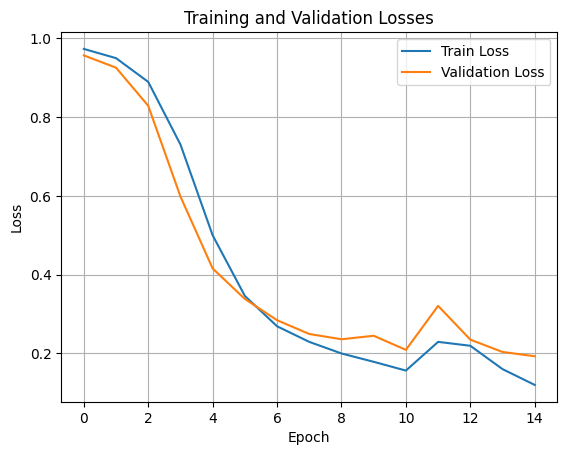

Accuracy: 0.9510
Precision: 0.9178
Recall: 0.9147
F1-score: 0.9162

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       706
         1.0       0.92      0.91      0.92       293

    accuracy                           0.95       999
   macro avg       0.94      0.94      0.94       999
weighted avg       0.95      0.95      0.95       999



In [ ]:
# train and evaluate the model on enron1
enron1_train_loss_history,enron1_valid_loss_history = train_evaluate_save_loop(model, train_loader_enron1, val_loader_enron1, optimizer, enron1_criterion,dataset_name='enron1')

# plot the losses
plot_losses(enron1_train_loss_history, enron1_valid_loss_history)

# test the model
test_model(model, test_loader_enron1)


### Enron2

Epoch: 1
Train Loss: 1.020 | Train Acc: 45.66%
Val. Loss: 1.011 |  Val. Acc: 72.44%

Epoch: 2
Train Loss: 0.981 | Train Acc: 79.12%
Val. Loss: 0.939 |  Val. Acc: 81.53%

Epoch: 3
Train Loss: 0.832 | Train Acc: 82.13%
Val. Loss: 0.705 |  Val. Acc: 79.27%

Epoch: 4
Train Loss: 0.547 | Train Acc: 83.33%
Val. Loss: 0.453 |  Val. Acc: 89.36%

Epoch: 5
Train Loss: 0.361 | Train Acc: 90.34%
Val. Loss: 0.350 |  Val. Acc: 91.34%

Epoch: 6
Train Loss: 0.277 | Train Acc: 92.94%
Val. Loss: 0.300 |  Val. Acc: 92.20%

Epoch: 7
Train Loss: 0.238 | Train Acc: 93.89%
Val. Loss: 0.273 |  Val. Acc: 93.92%

Epoch: 8
Train Loss: 0.200 | Train Acc: 95.23%
Val. Loss: 0.253 |  Val. Acc: 93.43%

Epoch: 9
Train Loss: 0.216 | Train Acc: 95.13%
Val. Loss: 0.277 |  Val. Acc: 94.13%

Epoch: 10
Train Loss: 0.173 | Train Acc: 95.31%
Val. Loss: 0.214 |  Val. Acc: 94.55%

Epoch: 11
Train Loss: 0.149 | Train Acc: 96.13%
Val. Loss: 0.222 |  Val. Acc: 94.21%

Epoch: 12
Train Loss: 0.130 | Train Acc: 96.81%
Val. Loss: 0.21

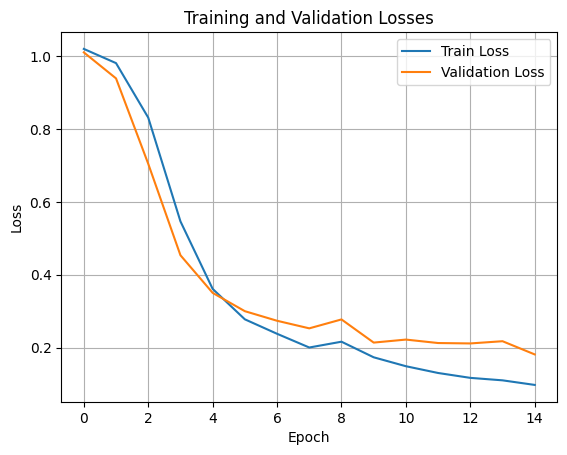

Accuracy: 0.9459
Precision: 0.8665
Recall: 0.9331
F1-score: 0.8986

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.95      0.96       866
         1.0       0.87      0.93      0.90       299

    accuracy                           0.95      1165
   macro avg       0.92      0.94      0.93      1165
weighted avg       0.95      0.95      0.95      1165



In [ ]:
model = LSTMNet(SIZE_OF_VOCAB, EMBEDDING_DIM, NUM_HIDDEN_NODES, NUM_OUTPUT_NODES, NUM_LAYERS, BIDIRECTION, DROPOUT).to(device)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# train and evaluate the model on enron1
enron2_train_loss_history,enron2_valid_loss_history = train_evaluate_save_loop(model, train_loader_enron2, val_loader_enron2, optimizer, enron2_criterion,dataset_name='enron2')

# plot the losses
plot_losses(enron2_train_loss_history, enron2_valid_loss_history)

# test the model
test_model(model, test_loader_enron2)


### SMS

Epoch: 1
Train Loss: 1.189 | Train Acc: 26.43%
Val. Loss: 1.186 |  Val. Acc: 53.39%

Epoch: 2
Train Loss: 1.161 | Train Acc: 66.28%
Val. Loss: 1.154 |  Val. Acc: 76.24%

Epoch: 3
Train Loss: 1.092 | Train Acc: 79.41%
Val. Loss: 1.051 |  Val. Acc: 86.67%

Epoch: 4
Train Loss: 0.829 | Train Acc: 86.23%
Val. Loss: 0.725 |  Val. Acc: 87.79%

Epoch: 5
Train Loss: 0.495 | Train Acc: 89.31%
Val. Loss: 0.601 |  Val. Acc: 92.50%

Epoch: 6
Train Loss: 0.378 | Train Acc: 92.56%
Val. Loss: 0.557 |  Val. Acc: 92.50%

Epoch: 7
Train Loss: 0.308 | Train Acc: 94.32%
Val. Loss: 0.568 |  Val. Acc: 94.74%

Epoch: 8
Train Loss: 0.262 | Train Acc: 95.66%
Val. Loss: 0.554 |  Val. Acc: 95.07%

Epoch: 9
Train Loss: 0.222 | Train Acc: 96.65%
Val. Loss: 0.574 |  Val. Acc: 95.07%

Epoch: 10
Train Loss: 0.192 | Train Acc: 97.24%
Val. Loss: 0.524 |  Val. Acc: 95.41%

Epoch: 11
Train Loss: 0.172 | Train Acc: 97.56%
Val. Loss: 0.507 |  Val. Acc: 95.19%

Epoch: 12
Train Loss: 0.150 | Train Acc: 98.12%
Val. Loss: 0.46

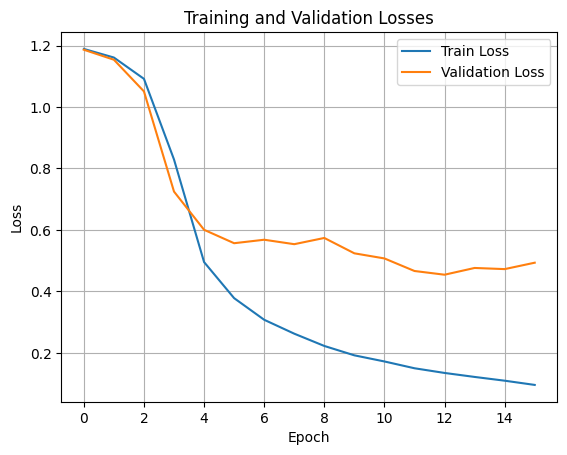

Accuracy: 0.9659
Precision: 0.9173
Recall: 0.8188
F1-score: 0.8652

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       966
         1.0       0.92      0.82      0.87       149

    accuracy                           0.97      1115
   macro avg       0.94      0.90      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:

model = LSTMNet(SIZE_OF_VOCAB, EMBEDDING_DIM, NUM_HIDDEN_NODES, NUM_OUTPUT_NODES, NUM_LAYERS, BIDIRECTION, DROPOUT).to(device)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# train and evaluate the model on enron1
sms_train_loss_history,sms_valid_loss_history = train_evaluate_save_loop(model, train_loader_sms, val_loader_sms, optimizer, sms_criterion,dataset_name='sms')

# plot the losses
plot_losses(sms_train_loss_history, sms_valid_loss_history)

# test the model
test_model(model, test_loader_sms)


### merged

Epoch: 1
Train Loss: 1.045 | Train Acc: 44.90%
Val. Loss: 0.998 |  Val. Acc: 70.53%

Epoch: 2
Train Loss: 0.741 | Train Acc: 79.28%
Val. Loss: 0.547 |  Val. Acc: 85.05%

Epoch: 3
Train Loss: 0.448 | Train Acc: 87.82%
Val. Loss: 0.409 |  Val. Acc: 89.32%

Epoch: 4
Train Loss: 0.350 | Train Acc: 90.75%
Val. Loss: 0.358 |  Val. Acc: 90.09%

Epoch: 5
Train Loss: 0.290 | Train Acc: 92.85%
Val. Loss: 0.324 |  Val. Acc: 91.42%

Epoch: 6
Train Loss: 0.239 | Train Acc: 94.21%
Val. Loss: 0.307 |  Val. Acc: 91.34%

Epoch: 7
Train Loss: 0.206 | Train Acc: 95.42%
Val. Loss: 0.276 |  Val. Acc: 93.33%

Epoch: 8
Train Loss: 0.174 | Train Acc: 96.25%
Val. Loss: 0.275 |  Val. Acc: 93.52%

Epoch: 9
Train Loss: 0.157 | Train Acc: 96.41%
Val. Loss: 0.255 |  Val. Acc: 94.24%

Epoch: 10
Train Loss: 0.134 | Train Acc: 97.08%
Val. Loss: 0.257 |  Val. Acc: 94.82%

Epoch: 11
Train Loss: 0.124 | Train Acc: 97.41%
Val. Loss: 0.245 |  Val. Acc: 94.59%

Epoch: 12
Train Loss: 0.095 | Train Acc: 98.13%
Val. Loss: 0.27

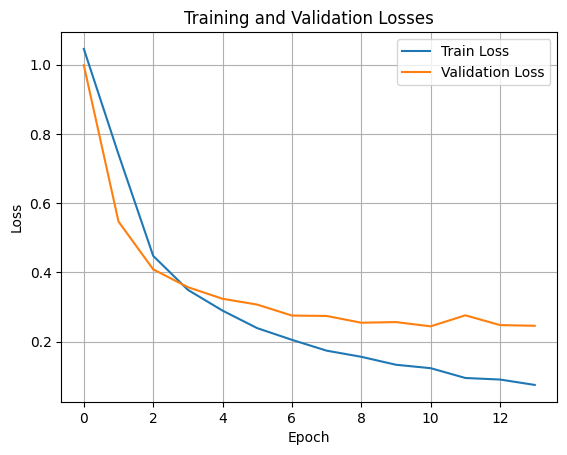

Accuracy: 0.9579
Precision: 0.8911
Recall: 0.9271
F1-score: 0.9087

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.97      0.97      2538
         1.0       0.89      0.93      0.91       741

    accuracy                           0.96      3279
   macro avg       0.93      0.95      0.94      3279
weighted avg       0.96      0.96      0.96      3279



In [ ]:
model = LSTMNet(SIZE_OF_VOCAB, EMBEDDING_DIM, NUM_HIDDEN_NODES, NUM_OUTPUT_NODES, NUM_LAYERS, BIDIRECTION, DROPOUT).to(device)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# train and evaluate the model on enron1
merged_train_loss_history,merged_valid_loss_history = train_evaluate_save_loop(model, train_loader_merged, val_loader_merged, optimizer, merged_criterion,dataset_name='merged')

# plot the losses
plot_losses(merged_train_loss_history,merged_valid_loss_history)

# test the model
test_model(model, test_loader_merged)
